##### Import Files / Packages

In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from inference import abc_function
from prior import GaussianPrior
from simulators import simulate_linear_regression
from summaries import regression_summary
from distance import euclidean_distance
from plots import plot_posterior, plot_observed_data, plot_comparison
from posterior import exact_linear_regression_posterior, sample_exact_posterior

##### Settings

In [2]:
TRUE_SLOPE = 2
TRUE_INTERCEPT = 1
TRUE_SD = 0.5

obs_rng = np.random.default_rng(1)
exact_rng = np.random.default_rng(2)

# ensure N_SAMPLES = n_simulations so the number of observations from both posteriors are the same
N_SAMPLES = 100000

conditions = [
    {"epsilon": 0.10, "n_simulations": 100000},
    {"epsilon": 0.30, "n_simulations": 100000},
    {"epsilon": 1.00, "n_simulations": 100000},
]

##### Define Fixed Values

In [3]:
x = np.linspace(0, 1, 50)

##### Define Prior

In [4]:
# We use a gaussian prior since the function exact_linear_regression_posterior requires a gaussian prior for calculation
prior_means = {"intercept": 0.0, "slope": 0.0}
prior_stds = {"intercept": 5.0, "slope": 5.0,}

prior = GaussianPrior(means = prior_means, stds = prior_stds)

# create mean and covariance matrix
# the covariance matrix must be diagonal since GaussianPrior samples independently
prior_mean = np.array([0.0, 0.0])
prior_covariance = np.diag([5.0 ** 2, 5.0 ** 2])

##### Get Observed Data

In [5]:
observed_data = simulate_linear_regression(intercept = TRUE_INTERCEPT,
                                           slope = TRUE_SLOPE,
                                           x = x, 
                                           sd = TRUE_SD, 
                                           rng = obs_rng)

##### Calculate Exact Posterior

In [6]:
posterior_mean, posterior_covariance = (
    exact_linear_regression_posterior(
        x = x,
        y = observed_data,
        noise_sd = TRUE_SD,
        prior_mean = prior_mean,
        prior_covariance = prior_covariance,
    )
)

##### Sample Exact Posterior

In [7]:
exact_samples = sample_exact_posterior(posterior_mean, posterior_covariance, N_SAMPLES, exact_rng)

##### Define Simulator and Summary Function

In [8]:
def abc_simulator(theta, abc_rng):
    slope = theta["slope"]
    intercept = theta["intercept"]

    return simulate_linear_regression(slope = slope, 
                                      intercept = intercept, 
                                      sd = TRUE_SD, 
                                      x = x, 
                                      rng = abc_rng)

def abc_summary(y):
    return regression_summary(x, y)

##### Run ABC

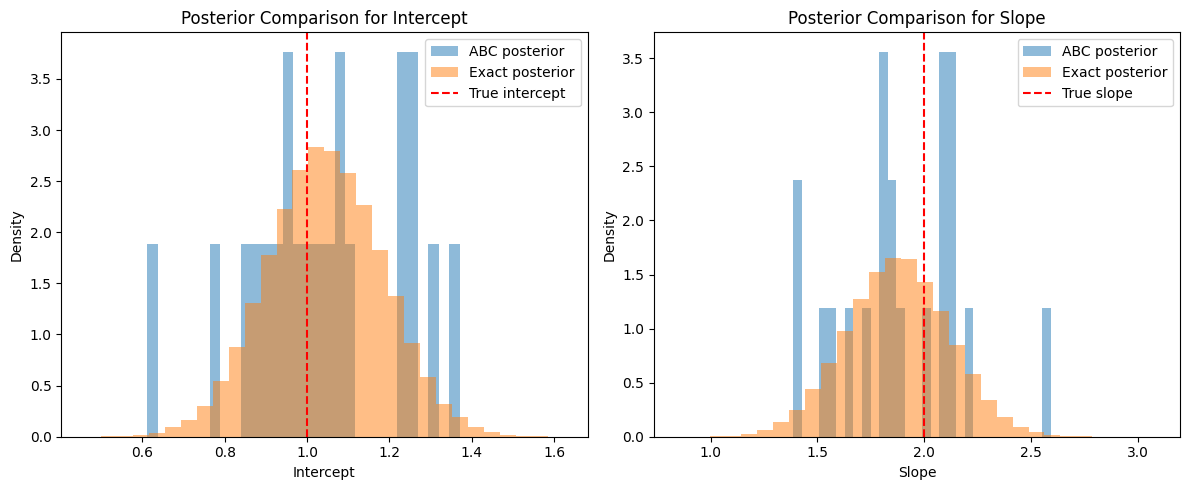

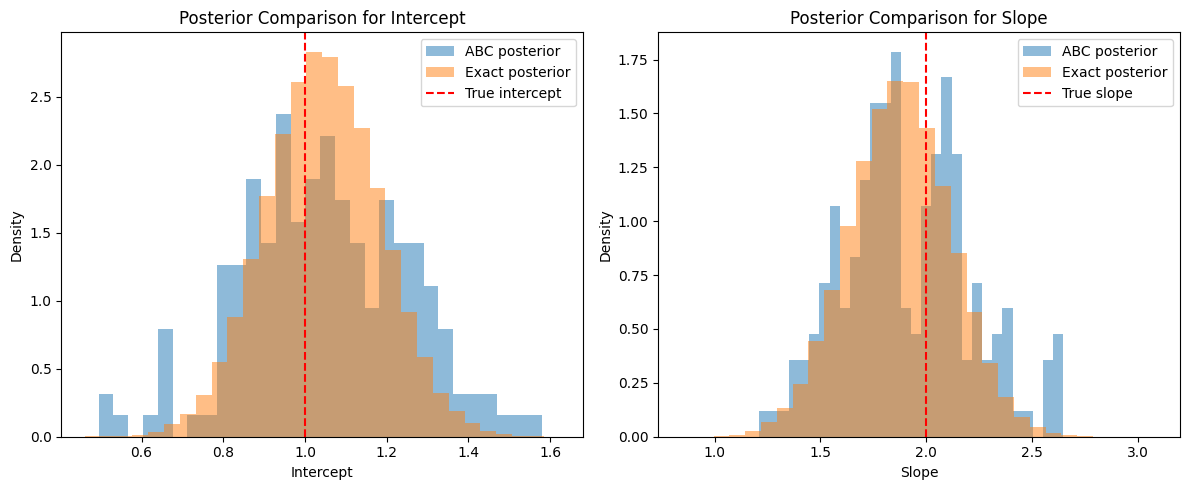

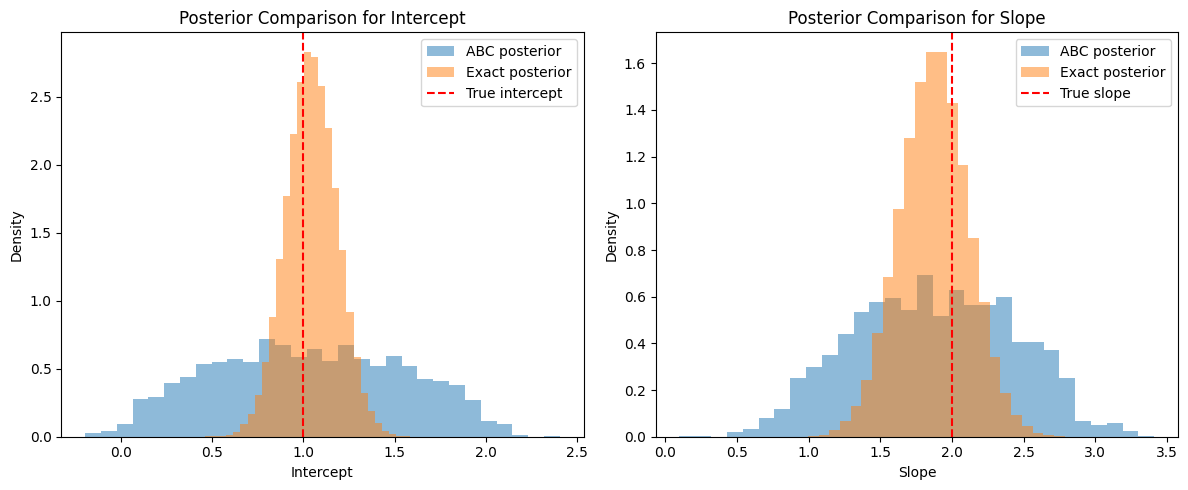

In [9]:
results = []

for condition in conditions:

    # set rng for ABC
    abc_rng = np.random.default_rng(3)

    # get epsilon and n_sims
    epsilon = condition["epsilon"]
    n_simulations = condition["n_simulations"]

    # run abc
    accepted_parameters, accepted_distances = abc_function(prior = prior,
                                                           simulator = abc_simulator,
                                                           observed_data = observed_data,
                                                           summary_fn = abc_summary,
                                                           distance_fn = euclidean_distance,
                                                           epsilon = epsilon,
                                                           n_simulations = n_simulations,
                                                           rng = abc_rng)
    
    # check if 0 parameters collected
    if len(accepted_parameters) == 0:
        print(f"No samples accepted for epsilon={epsilon}.")
        continue

    # collect array of accepted parameters of each parameter
    intercept_samples = np.array([sample["intercept"] for sample in accepted_parameters])
    slope_samples = np.array([sample["slope"] for sample in accepted_parameters])

    results.append({
        "epsilon": epsilon,
        "n_simulations": n_simulations,
        "accepted": len(accepted_parameters),
        "acceptance_rate": len(accepted_parameters) / n_simulations,
        "abc_intercept_mean": np.mean(intercept_samples),
        "abc_slope_mean": np.mean(slope_samples),
        "intercept_mean_error": (np.mean(intercept_samples) - posterior_mean[0]),
        "slope_mean_error": (np.mean(slope_samples) - posterior_mean[1]),
    })

    plot_comparison(
        accepted_parameters,
        exact_samples,
        1,
        2,
    )

    plt.show()

##### Get Results

In [10]:
results_df = pd.DataFrame(results)
results_df

,epsilon,n_simulations,accepted,acceptance_rate,abc_intercept_mean,abc_slope_mean,intercept_mean_error,slope_mean_error
0,0.1,100000,21,0.00021,1.039676,1.888719,-0.004459,0.013486
1,0.3,100000,175,0.00175,1.050366,1.909592,0.006230,0.034359
2,1.0,100000,1846,0.01846,1.027631,1.870838,-0.016505,-0.004395
